In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression as SkLogReg

plt.rcParams["figure.dpi"] = 100
np.set_printoptions(precision=4, suppress=True)

In [11]:
class StandardScaler:

    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        self.std_[self.std_ == 0] = 1.0
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        return self.fit(X).transform(X)


class LogisticRegression:

    def __init__(self, lr=0.1, n_iters=1000, lam=0.0, tol=1e-8, verbose=False):
        self.lr = lr
        self.n_iters = n_iters
        self.lam = lam
        self.tol = tol
        self.verbose = verbose

        self.w_ = None
        self.b_ = 0.0
        self.loss_history_ = []

    def _sigmoid(self, z):
        out = np.empty_like(z, dtype=float)
        pos = z >= 0
        out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
        ez = np.exp(z[~pos])
        out[~pos] = ez / (1.0 + ez)
        return out

    def _loss(self, y, p):
        eps = 1e-12
        p = np.clip(p, eps, 1 - eps)
        ce = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
        return ce + 0.5 * self.lam * np.sum(self.w_ ** 2)

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        n, d = X.shape

        self.w_ = np.zeros(d)
        self.b_ = 0.0
        self.loss_history_ = []

        for it in range(self.n_iters):
            p = self._sigmoid(X @ self.w_ + self.b_)

            err = p - y
            grad_w = X.T @ err / n + self.lam * self.w_
            grad_b = err.mean()

            self.w_ -= self.lr * grad_w
            self.b_ -= self.lr * grad_b

            loss = self._loss(y, self._sigmoid(X @ self.w_ + self.b_))
            self.loss_history_.append(loss)

            if self.verbose and it % 100 == 0:
                print(f"iter {it:4d} | loss = {loss:.5f}")

            if it > 0 and abs(self.loss_history_[-2] - loss) < self.tol:
                break

        self.n_iter_ = len(self.loss_history_)
        return self

    def predict_proba(self, X):
        if self.w_ is None:
            raise RuntimeError("Call fit() before predicting")
        return self._sigmoid(np.asarray(X, dtype=float) @ self.w_ + self.b_)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    def score(self, X, y):
        return np.mean(self.predict(X) == np.asarray(y))

    def __repr__(self):
        return f"LogisticRegression(lr={self.lr}, n_iters={self.n_iters}, lam={self.lam})"

In [13]:
class BinaryMetrics:

    def __init__(self, y_true, y_pred):
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        self.tp = int(np.sum((y_true == 1) & (y_pred == 1)))
        self.tn = int(np.sum((y_true == 0) & (y_pred == 0)))
        self.fp = int(np.sum((y_true == 0) & (y_pred == 1)))
        self.fn = int(np.sum((y_true == 1) & (y_pred == 0)))

    @property
    def accuracy(self):
        return (self.tp + self.tn) / (self.tp + self.tn + self.fp + self.fn)

    @property
    def precision(self):
        d = self.tp + self.fp
        return self.tp / d if d else 0.0

    @property
    def recall(self):
        d = self.tp + self.fn
        return self.tp / d if d else 0.0

    @property
    def f1(self):
        p, r = self.precision, self.recall
        return 2 * p * r / (p + r) if (p + r) else 0.0

    def confusion_matrix(self):
        return np.array([[self.tn, self.fp],
                         [self.fn, self.tp]])

    def report(self):
        print(f"Accuracy : {self.accuracy:.4f}")
        print(f"Precision: {self.precision:.4f}")
        print(f"Recall   : {self.recall:.4f}")
        print(f"F1-score : {self.f1:.4f}")
        print("Confusion matrix (rows = actual, cols = predicted):")
        print(self.confusion_matrix())

In [6]:
X2, y2 = make_classification(n_samples=300, n_features=2, n_informative=2,
                             n_redundant=0, n_clusters_per_class=1,
                             class_sep=1.2, flip_y=0.03, random_state=11)

sc2 = StandardScaler()
X2s = sc2.fit_transform(X2)

model2 = LogisticRegression(lr=0.5, n_iters=2000, lam=0.0).fit(X2s, y2)
print(model2)
print("Weights:", model2.w_, "| bias:", round(model2.b_, 4))
print("Iterations used:", model2.n_iter_)
print("Training accuracy:", round(model2.score(X2s, y2), 4))

LogisticRegression(lr=0.5, n_iters=2000, lam=0.0)
Weights: [4.0225 0.6585] | bias: 0.207
Iterations used: 651
Training accuracy: 0.9233


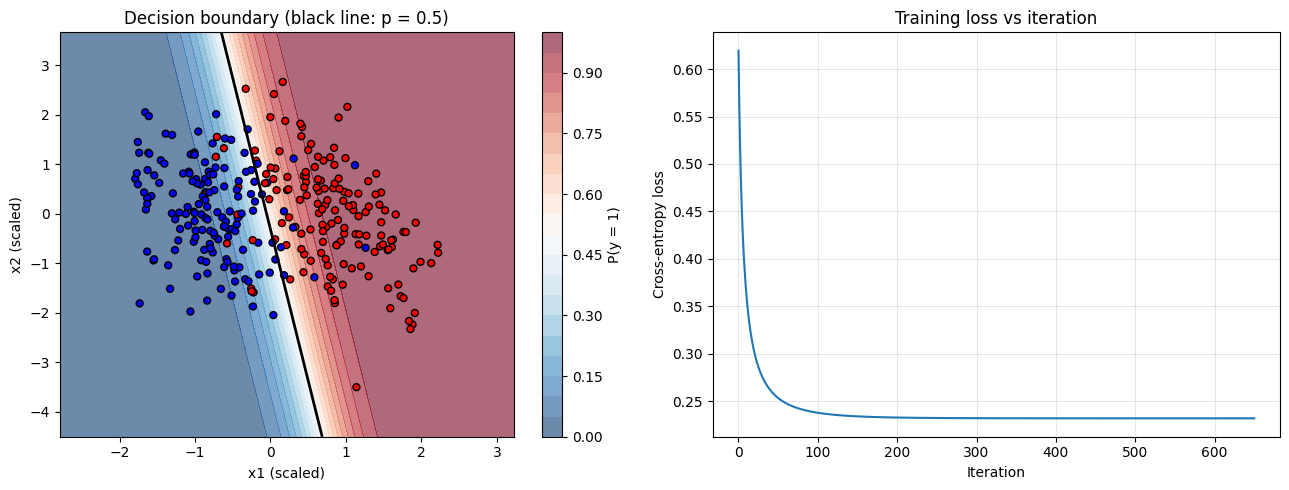

In [15]:
xx, yy = np.meshgrid(np.linspace(X2s[:, 0].min() - 1, X2s[:, 0].max() + 1, 300),
                     np.linspace(X2s[:, 1].min() - 1, X2s[:, 1].max() + 1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
probs = model2.predict_proba(grid).reshape(xx.shape)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

cs = ax[0].contourf(xx, yy, probs, levels=20, cmap="RdBu_r", alpha=0.6)
ax[0].contour(xx, yy, probs, levels=[0.5], colors="black", linewidths=2)
ax[0].scatter(X2s[:, 0], X2s[:, 1], c=y2, cmap="bwr", edgecolor="k", s=25)
ax[0].set_title("Decision boundary (black line: p = 0.5)")
ax[0].set_xlabel("x1 (scaled)"); ax[0].set_ylabel("x2 (scaled)")
plt.colorbar(cs, ax=ax[0], label="P(y = 1)")

ax[1].plot(model2.loss_history_)
ax[1].set_title("Training loss vs iteration")
ax[1].set_xlabel("Iteration"); ax[1].set_ylabel("Cross-entropy loss")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [16]:
data = load_breast_cancer()
X, y = data.data, data.target
print("Shape:", X.shape)
print("Class counts (0 = malignant, 1 = benign):", np.bincount(y))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)      # note: uses TRAIN mean/std, no leakage

Shape: (569, 30)
Class counts (0 = malignant, 1 = benign): [212 357]


In [17]:
clf = LogisticRegression(lr=0.1, n_iters=3000, lam=0.01)
clf.fit(X_train_s, y_train)

print(clf)
print("Iterations used:", clf.n_iter_)
print("Final training loss:", round(clf.loss_history_[-1], 5))
print()
print("--- TEST SET ---")
BinaryMetrics(y_test, clf.predict(X_test_s)).report()

LogisticRegression(lr=0.1, n_iters=3000, lam=0.01)
Iterations used: 2308
Final training loss: 0.09692

--- TEST SET ---
Accuracy : 0.9860
Precision: 0.9889
Recall   : 0.9889
F1-score : 0.9889
Confusion matrix (rows = actual, cols = predicted):
[[52  1]
 [ 1 89]]


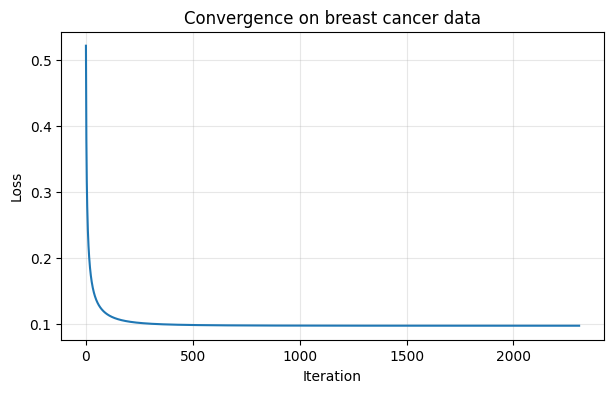

In [18]:
plt.figure(figsize=(7, 4))
plt.plot(clf.loss_history_)
plt.xlabel("Iteration"); plt.ylabel("Loss")
plt.title("Convergence on breast cancer data")
plt.grid(alpha=0.3)
plt.show()

In [19]:
raw = LogisticRegression(lr=0.1, n_iters=3000, lam=0.01, tol=0).fit(X_train, y_train)
print("Unscaled -> final loss:", round(raw.loss_history_[-1], 3),
      "| train acc:", round(raw.score(X_train, y_train), 4),
      "| test acc:", round(raw.score(X_test, y_test), 4))
print("Scaled   -> final loss:", round(clf.loss_history_[-1], 3),
      "| train acc:", round(clf.score(X_train_s, y_train), 4),
      "| test acc:", round(clf.score(X_test_s, y_test), 4))

Unscaled -> final loss: 501.303 | train acc: 0.5986 | test acc: 0.6364
Scaled   -> final loss: 0.097 | train acc: 0.9859 | test acc: 0.986


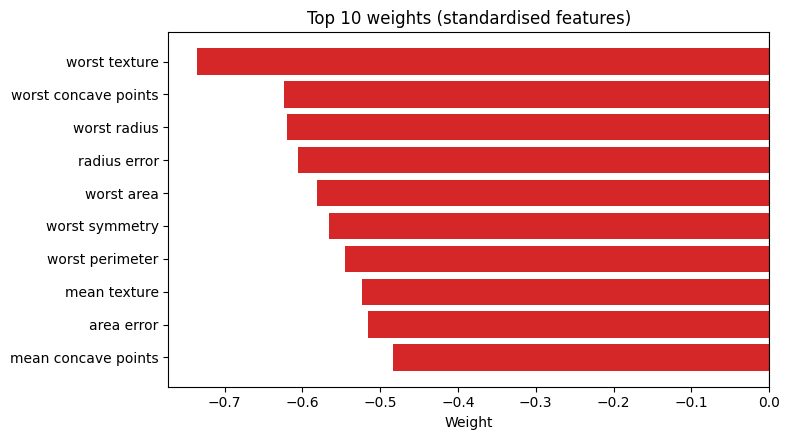

In [20]:
order = np.argsort(np.abs(clf.w_))[::-1][:10]
names = data.feature_names[order]
vals = clf.w_[order]

plt.figure(figsize=(8, 4.5))
plt.barh(names[::-1], vals[::-1], color=["tab:red" if v < 0 else "tab:blue" for v in vals[::-1]])
plt.axvline(0, color="black", lw=0.8)
plt.title("Top 10 weights (standardised features)")
plt.xlabel("Weight")
plt.tight_layout(); plt.show()

lr = 0.001  -> loss after 300 iters: 0.39749
lr = 0.01   -> loss after 300 iters: 0.16127
lr = 0.1    -> loss after 300 iters: 0.09999
lr = 2.0    -> loss after 300 iters: 0.09691
lr = 10     -> loss after 300 iters: 0.09799
lr = 30     -> loss after 300 iters: 0.24655


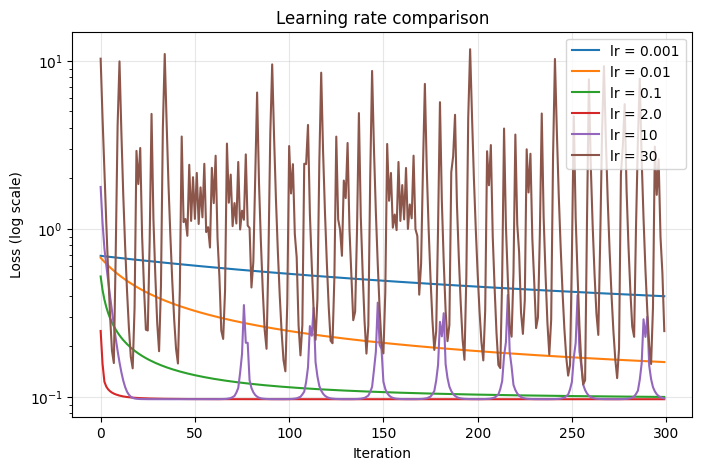

In [21]:
lrs = [0.001, 0.01, 0.1, 2.0, 10, 30]
plt.figure(figsize=(8, 5))
for lr in lrs:
    m = LogisticRegression(lr=lr, n_iters=300, lam=0.01, tol=0).fit(X_train_s, y_train)
    plt.plot(m.loss_history_, label=f"lr = {lr}")
    print(f"lr = {lr:<6} -> loss after 300 iters: {m.loss_history_[-1]:.5f}")

plt.yscale("log")
plt.xlabel("Iteration"); plt.ylabel("Loss (log scale)")
plt.title("Learning rate comparison")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [22]:
lams = [0.0, 0.001, 0.01, 0.1, 1.0]
rows = []
for lam in lams:
    m = LogisticRegression(lr=0.1, n_iters=3000, lam=lam).fit(X_train_s, y_train)
    rows.append((lam, np.linalg.norm(m.w_), m.score(X_train_s, y_train), m.score(X_test_s, y_test)))

print(f"{'lambda':>8} | {'||w||':>8} | {'train acc':>9} | {'test acc':>8}")
for lam, nw, tr, te in rows:
    print(f"{lam:>8} | {nw:8.3f} | {tr:9.4f} | {te:8.4f}")

  lambda |    ||w|| | train acc | test acc
     0.0 |    4.175 |    0.9883 |   0.9790
   0.001 |    3.727 |    0.9883 |   0.9860
    0.01 |    2.291 |    0.9859 |   0.9860
     0.1 |    1.105 |    0.9789 |   0.9510
     1.0 |    0.443 |    0.9366 |   0.9441


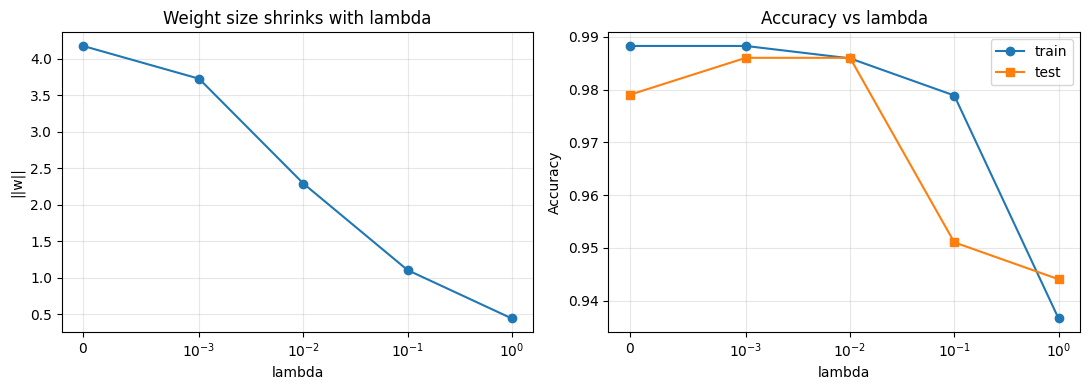

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot([r[0] for r in rows], [r[1] for r in rows], marker="o")
ax[0].set_xscale("symlog", linthresh=1e-3)
ax[0].set_xlabel("lambda"); ax[0].set_ylabel("||w||"); ax[0].set_title("Weight size shrinks with lambda")

ax[1].plot([r[0] for r in rows], [r[2] for r in rows], marker="o", label="train")
ax[1].plot([r[0] for r in rows], [r[3] for r in rows], marker="s", label="test")
ax[1].set_xscale("symlog", linthresh=1e-3)
ax[1].set_xlabel("lambda"); ax[1].set_ylabel("Accuracy"); ax[1].set_title("Accuracy vs lambda")
ax[1].legend()
for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [24]:
proba = clf.predict_proba(X_test_s)

print(f"{'thr':>5} | {'precision':>9} | {'recall':>7} | {'accuracy':>8}")
for t in [0.3, 0.5, 0.7, 0.9]:
    m = BinaryMetrics(y_test, (proba >= t).astype(int))
    print(f"{t:>5} | {m.precision:9.4f} | {m.recall:7.4f} | {m.accuracy:8.4f}")

  thr | precision |  recall | accuracy
  0.3 |    0.9278 |  1.0000 |   0.9510
  0.5 |    0.9889 |  0.9889 |   0.9860
  0.7 |    0.9881 |  0.9222 |   0.9441
  0.9 |    1.0000 |  0.7778 |   0.8601


In [25]:
class ROC:

    def __init__(self, y_true, scores):
        y_true = np.asarray(y_true)
        thresholds = np.concatenate(([1.1], np.sort(np.unique(scores))[::-1], [-0.1]))
        P = np.sum(y_true == 1)
        N = np.sum(y_true == 0)
        tpr, fpr = [], []
        for t in thresholds:
            pred = scores >= t
            tpr.append(np.sum(pred & (y_true == 1)) / P)
            fpr.append(np.sum(pred & (y_true == 0)) / N)
        self.fpr = np.array(fpr)
        self.tpr = np.array(tpr)

    @property
    def auc(self):
        # trapezoid rule
        return float(np.sum(np.diff(self.fpr) * (self.tpr[1:] + self.tpr[:-1]) / 2))

AUC (my implementation): 0.9975


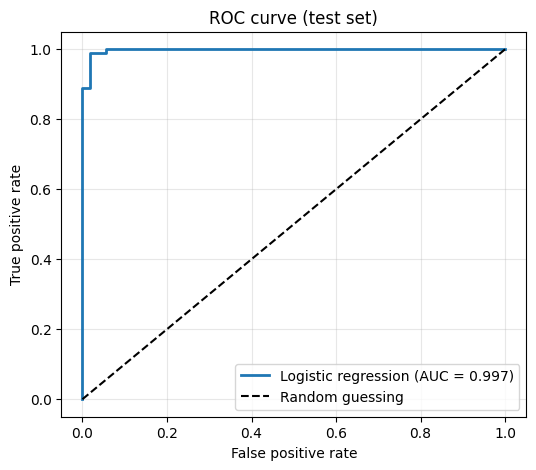

In [26]:
roc = ROC(y_test, proba)
print("AUC (my implementation):", round(roc.auc, 4))

plt.figure(figsize=(6, 5))
plt.plot(roc.fpr, roc.tpr, lw=2, label=f"Logistic regression (AUC = {roc.auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guessing")
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title("ROC curve (test set)")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [27]:
lam = 0.01
n = len(X_train_s)

mine = LogisticRegression(lr=0.1, n_iters=20000, lam=lam, tol=1e-12).fit(X_train_s, y_train)
sk = SkLogReg(C=1.0 / (n * lam), max_iter=10000).fit(X_train_s, y_train)

print("Mine    test accuracy:", round(mine.score(X_test_s, y_test), 4))
print("sklearn test accuracy:", round(sk.score(X_test_s, y_test), 4))
print()
print("Max |w_mine - w_sklearn| :", np.abs(mine.w_ - sk.coef_.ravel()).max())
print("|b_mine - b_sklearn|     :", abs(mine.b_ - sk.intercept_[0]))
print("Predictions identical on test set:",
      np.array_equal(mine.predict(X_test_s), sk.predict(X_test_s)))

Mine    test accuracy: 0.986
sklearn test accuracy: 0.986

Max |w_mine - w_sklearn| : 0.0016873472131522377
|b_mine - b_sklearn|     : 0.0006517499250967562
Predictions identical on test set: True
